In [2]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
class HandwrittenAlphabetDataset(Dataset):
    Labels = [chr(ord('A') + i) for i in range(26)]

    def __init__(self, csv_path, transforms = None):
        df = pd.read_csv(csv_path, header = None)

        self.labels = df.iloc[:, 0].values.astype(np.int64)
        self.images = df.iloc[:, 1:].values.astype(np.float32) / 255.0

        self.transforms = transforms

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        image = torch.tensor(image).reshape(1, 28, 28)

        if self.transforms:
            image = self.transforms(image)

        return image, label

In [4]:
CSV_PATH = 'data\Handwritten Data.csv'

dataset = HandwrittenAlphabetDataset(CSV_PATH)

print(f'Num of samples: {len(dataset)}')
print(f'Classes: {HandwrittenAlphabetDataset.Labels}')

sample_img, sample_label = dataset[0]
print(f'Image shape: {sample_img.shape}')
print(f'Class: {HandwrittenAlphabetDataset.Labels[sample_label]} (Index: {sample_label})')

<>:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
D:\Cache\Temp\ipykernel_19632\3024058987.py:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
  CSV_PATH = 'data\Handwritten Data.csv'


Num of samples: 372451
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Image shape: torch.Size([1, 28, 28])
Class: A (Index: 0)


In [5]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_dataset)} samples;  Test: {len(test_dataset)} samples')

Train: 297960 samples;  Test: 74491 samples


In [6]:
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

class HWDataLinearModel(nn.Module):
    def __init__(self, input_size = 784, num_classes = 26):
        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits
    
model = HWDataLinearModel(input_size=784, num_classes=26).to(device)
print(model)

HWDataLinearModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=26, bias=True)
  )
)


In [7]:
def train_loop(dataloader, model, loss_fn, optimizer, epoch):
    model.train()

    total_loss = 0.0
    correct    = 0 
    total      = 0

    tdqm_loader = tqdm(dataloader, unit = 'batch', desc = f'Epoch {epoch}', total = len(dataloader))
    for X, y in tdqm_loader:
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        correct += (pred.argmax(1) == y).sum().item()
        total += X.size(0)

        tdqm_loader.set_postfix(loss = f'{loss.item():.4f}')

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def test_loop(dataloader, model, loss_fn):
    model.eval()

    total_loss = 0.0
    correct    = 0
    total      = 0

    with torch.no_grad(): 
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)

            total_loss += loss_fn(pred, y).item() * X.size(0)
            correct += (pred.argmax(1) == y).sum().item()
            total += X.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    print(f"  Test  → Loss: {avg_loss:.4f} | Accuracy: {100 * accuracy:.1f}%")
    return avg_loss, accuracy

In [8]:
EPOCHS = 15
LEARNING_RATE = 1e-3

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

history = {
    "train_loss": [], "train_acc": [],
    "test_loss": [], "test_acc": [],
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_loop(train_loader, model, loss_fn, optimizer, epoch)
    test_loss, test_acc = test_loop(test_loader, model, loss_fn)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

torch.save(model, 'HWD_model.pth')
torch.save(model.state_dict(), "HWD_model_state.pth")
print("\nModel Saved.")

Epoch 0: 100%|██████████| 1164/1164 [00:30<00:00, 38.10batch/s, loss=0.2225]


  Test  → Loss: 0.1325 | Accuracy: 96.1%


Epoch 1: 100%|██████████| 1164/1164 [00:30<00:00, 38.17batch/s, loss=0.1572]


  Test  → Loss: 0.0933 | Accuracy: 97.3%


Epoch 2: 100%|██████████| 1164/1164 [00:30<00:00, 38.40batch/s, loss=0.0954]


...

  Test  → Loss: 0.0417 | Accuracy: 98.8%


Epoch 13: 100%|██████████| 1164/1164 [00:30<00:00, 38.14batch/s, loss=0.0325]


  Test  → Loss: 0.0412 | Accuracy: 98.9%


Epoch 14: 100%|██████████| 1164/1164 [00:30<00:00, 38.16batch/s, loss=0.0289]


  Test  → Loss: 0.0423 | Accuracy: 98.8%

Model Saved.


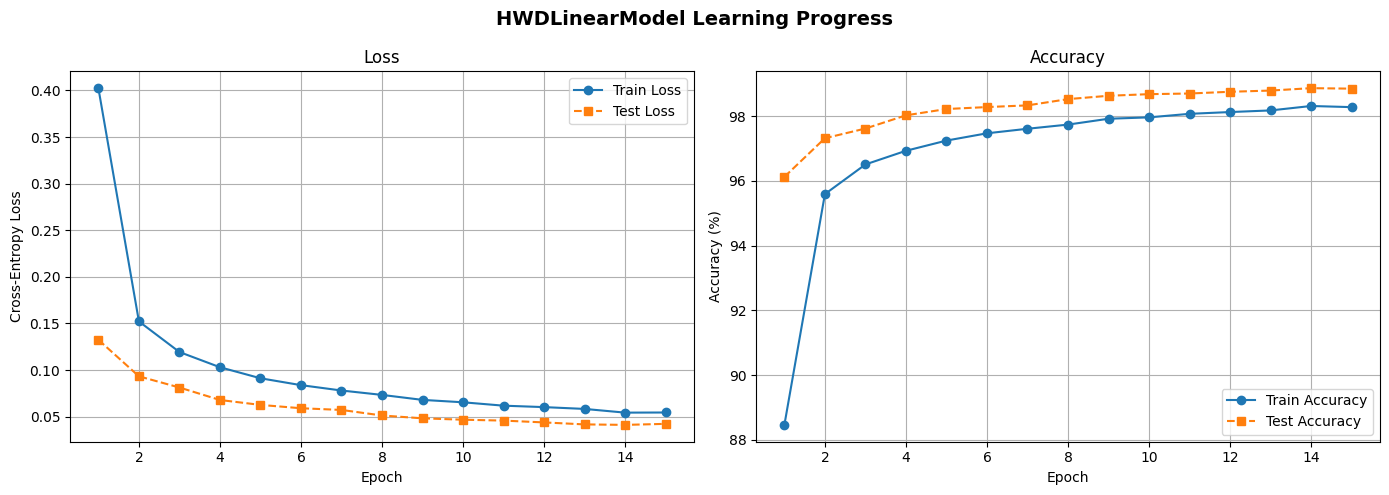


Final Test accuracy: 98.8%


In [9]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("HWDLinearModel Learning Progress", fontsize=14, fontweight="bold")

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss",  marker="o")
axes[0].plot(epochs_range, history["test_loss"],  label="Test Loss",   marker="s", linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, [a * 100 for a in history["train_acc"]], label="Train Accuracy", marker="o")
axes[1].plot(epochs_range, [a * 100 for a in history["test_acc"]],  label="Test Accuracy",  marker="s", linestyle="--")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
print(f"\nFinal Test accuracy: {history['test_acc'][-1] * 100:.1f}%")

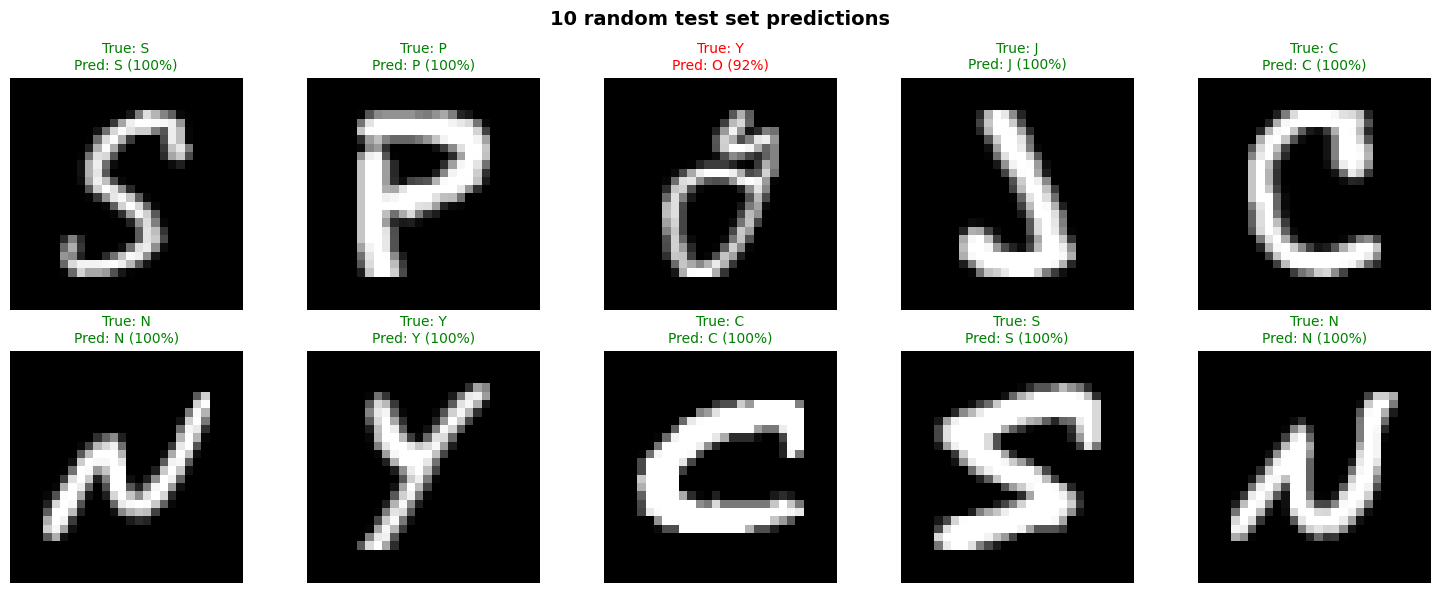

In [22]:
import random

loaded_model = HWDataLinearModel(input_size=784, num_classes=26)
loaded_model.load_state_dict(torch.load("HWD_model_state.pth", map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()

random_indices = random.sample(range(len(test_dataset)), 10)
LABELS = HandwrittenAlphabetDataset.Labels

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("10 random test set predictions", fontsize=14, fontweight="bold")

with torch.no_grad():
    for ax, idx in zip(axes.flatten(), random_indices):
        image, true_label = test_dataset[idx]

        # Передбачення
        input_tensor = image.unsqueeze(0).to(device)
        logits = loaded_model(input_tensor)
        probs  = torch.softmax(logits, dim=1)
        pred_label = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_label].item()

        # Відображення
        ax.imshow(image.squeeze().numpy(), cmap="gray")
        ax.axis("off")

        is_correct = pred_label == true_label
        color = "green" if is_correct else "red"
        title = (
            f"True: {LABELS[true_label]}\n"
            f"Pred: {LABELS[pred_label]} ({confidence:.0%})"
        )
        ax.set_title(title, color=color, fontsize=10)

plt.tight_layout()
plt.show()